<a href="https://colab.research.google.com/github/jjlizcano/Sistema-recomendaciones-cultivo/blob/main/codigo_proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Sistema de recomendaciones de cultivos**


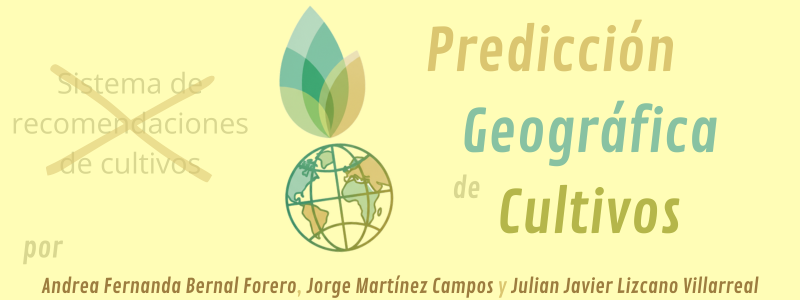

In [93]:
# 1. Instalar dependencias adicionales
!pip install gdown seaborn --quiet
!pip install pycountry_convert
# 2. Clonar o actualizar el repositorio
import os

REPO_URL = "https://github.com/jjlizcano/Sistema-recomendaciones-cultivo.git"
REPO_DIR = "Sistema-recomendaciones-cultivo"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}
else:
    %cd {REPO_DIR}
    !git pull
    %cd ..

print("Repositorio listo en:", REPO_DIR)

/content/Sistema-recomendaciones-cultivo
Already up to date.
/content
Repositorio listo en: Sistema-recomendaciones-cultivo


In [94]:
# 3. Semilla reproducible
import numpy as np, random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

In [95]:
# 4. Verificar entorno
import sys, pandas as pd

print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("Numpy:", np.__version__)

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Pandas: 2.2.2
Numpy: 2.0.2


In [96]:
# 5. Cargar dataset desde /data
csv_path = f"{REPO_DIR}/data/FAOSTAT_data_en_9-1-2025.csv"

try:
    df = pd.read_csv(csv_path)
    print("Dataset cargado correctamente")
    print("Registros en el dataset:", len(df))

except FileNotFoundError:
    print(f" Error: No se encontró el archivo {csv_path}")

Dataset cargado correctamente
Registros en el dataset: 29272


# 1. **Exploración inicial del dataset: dimensiones, variables y vista preliminar**



In [97]:
# === Punto 1 ===
# === Shape del DataFrame ===
print("\n=== Shape del DataFrame ===")
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

# === Columnas del DataFrame ===

print("\n=== Columnas del DataFrame ===")
print("Las columnas son:")
for column in df.columns:
    print(f" - {column}")

# === Primeras 5 filas del DataFrame ===

print("\n=== Primeras 5 filas del DataFrame ===")
print(display(df.head()))

# === Tipos de variables ===

print("\n === Tipos de variables ===")
print("Los tipos de variables son:")
print(display(df.dtypes))


=== Shape del DataFrame ===
El dataset tiene 29272 filas y 15 columnas.

=== Columnas del DataFrame ===
Las columnas son:
 - Domain Code
 - Domain
 - Area Code (M49)
 - Area
 - Element Code
 - Element
 - Item Code (CPC)
 - Item
 - Year Code
 - Year
 - Unit
 - Value
 - Flag
 - Flag Description
 - Note

=== Primeras 5 filas del DataFrame ===


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,1371.0,"Almonds, in shell",2023,2023,ha,37000.0,A,Official figure,NaN
1,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,1371.0,"Almonds, in shell",2023,2023,kg/ha,1810.8,A,Official figure,NaN
2,QCL,Crops and livestock products,4,Afghanistan,5510,Production,1371.0,"Almonds, in shell",2023,2023,t,67000.0,A,Official figure,NaN
3,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2023,2023,ha,25439.0,E,Estimated value,NaN
4,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2023,2023,kg/ha,704.0,E,Estimated value,NaN


None

 === Tipos de variables ===
Los tipos de variables son:


,0
Domain Code,object
Domain,object
Area Code (M49),int64
Area,object
Element Code,int64
Element,object
Item Code (CPC),float64
Item,object
Year Code,int64
Year,int64


None


# 2. **Análisis descriptivo de variables mediante *describe()***  

In [98]:
from IPython.display import display

# --- Reclasificación rápida ---
df['Year'] = df['Year'].astype('Int64')
df['Value'] = df['Value'].astype(float)

cat_cols = [
    'Domain Code','Domain','Area Code (M49)','Area',
    'Element Code','Element','Item Code (CPC)','Item',
    'Unit','Flag','Flag Description','Note'
]
for c in cat_cols:
    if c in df.columns:
        df[c] = df[c].astype('category')

print(" Resumen de variables numéricas")
display(df.describe().T.round(2))

print("\n Resumen de variables categóricas")
display(df.describe(include=['category']).T)

 Resumen de variables numéricas


,count,mean,std,min,25%,50%,75%,max
Year Code,29272.0,2023.0,0.0,2023.0,2023.0,2023.0,2023.0,2023.0
Year,29272.0,2023.0,0.0,2023.0,2023.0,2023.0,2023.0,2023.0
Value,28357.0,478813.812892,7854987.90734,0.0,1000.0,6087.0,30393.75,782585836.0



 Resumen de variables categóricas


,count,unique,top,freq
Domain Code,29272,1,QCL,29272
Domain,29272,1,Crops and livestock products,29272
Area Code (M49),29272,200,159,369
Area,29272,200,China,369
Element Code,29272,3,5510,10161
Element,29272,3,Production,10161
Item Code (CPC),29272.0,161.0,1290.9,567.0
Item,29272,161,"Other vegetables, fresh n.e.c.",567
Unit,29272,3,t,10161
Flag,29272,5,A,13427


# 3. **Limpieza de datos**

In [99]:
# 0)Copia de trabajo
df_reduced = df.copy()

# 1)Columnas redundantes / IDs
drop_cols = [
    'Domain Code',      # constante
    'Domain',           # constante
    'Year',             # todos los datos o filas son del año 2023
    'Year Code',        # duplicado de 'Year'
    'Note',             # vacío
    'Area Code (M49)',  # ID redundante
    'Element Code',     # ID redundante
    'Item Code (CPC)',  # ID redundante
    'Flag'              # nos quedamos solo con Flag Description
]

# 2)Eliminar
drop_cols = [c for c in drop_cols if c in df_reduced.columns]
df_reduced = df_reduced.drop(columns=drop_cols, errors='ignore')

# 3) Reporte breve
print("Columnas eliminadas:", drop_cols if drop_cols else "Ninguna")
print("Shape antes:", df.shape, "→ después:", df_reduced.shape)

# 4) Vista rápida del resultado
display(df_reduced.head(10))

Columnas eliminadas: ['Domain Code', 'Domain', 'Year', 'Year Code', 'Note', 'Area Code (M49)', 'Element Code', 'Item Code (CPC)', 'Flag']
Shape antes: (29272, 15) → después: (29272, 6)


,Area,Element,Item,Unit,Value,Flag Description
0,Afghanistan,Area harvested,"Almonds, in shell",ha,37000.00,Official figure
1,Afghanistan,Yield,"Almonds, in shell",kg/ha,1810.80,Official figure
2,Afghanistan,Production,"Almonds, in shell",t,67000.00,Official figure
3,Afghanistan,Area harvested,"Anise, badian, coriander, cumin, caraway, fenn...",ha,25439.00,Estimated value
4,Afghanistan,Yield,"Anise, badian, coriander, cumin, caraway, fenn...",kg/ha,704.00,Estimated value
5,Afghanistan,Production,"Anise, badian, coriander, cumin, caraway, fenn...",t,17908.59,Estimated value
6,Afghanistan,Area harvested,Apples,ha,31000.00,Official figure
7,Afghanistan,Yield,Apples,kg/ha,10451.60,Official figure
8,Afghanistan,Production,Apples,t,324000.00,Official figure
9,Afghanistan,Area harvested,Apricots,ha,22008.00,Imputed value


## 3.1. **Contexto después de la limpieza**

Tras realizar la primera limpieza del dataset (eliminación de columnas redundantes como códigos, notas y años duplicados), el archivo quedó reducido a seis columnas principales, cada una con un rol específico:

- ***Area*** → representa el país al que pertenece el registro.

- ***Element*** → indica el tipo de información reportada, que puede ser Producción, Rendimiento o Superficie cosechada.

- ***Item*** → corresponde al cultivo específico al que se refiere el registro (ejemplo: arroz, maíz, trigo).

- ***Unit*** → define la unidad de medida en que se expresa el valor, como toneladas, hectáreas o kg/ha.

- ***Value*** → es el dato numérico asociado al elemento, expresado en la unidad correspondiente.

- ***Flag Description*** → señala la calidad o naturaleza del dato, por ejemplo Official figure o Estimated value.

Al observar la estructura en este punto, notamos que la información aún estaba organizada de manera que cada fila contenía un único “Elemento” dentro de la columna *Element*.

Esto significa que, para un mismo país y cultivo, aparecían varias filas distintas:

- Una con la **superficie cosechada (Area harvested)** en hectáreas.

- Otra con el **rendimiento (Yield)** en kg/ha.

- Otra con la **producción (Production)** en toneladas.

En otras palabras, la variable *Value* estaba compartida entre distintos tipos de datos, lo que hacía que los registros estuvieran fragmentados.

In [100]:
# Partimos de d (ya filtrado por unidad-canónica por Element) o de df_reduced si vienes de antes:
d = df_reduced.copy()

# Limpieza mínima
text_cols = ['Area','Item','Element','Unit','Flag Description']
for c in text_cols:
    if c in d.columns:
        d[c] = d[c].astype('string').str.strip()
d['Value'] = pd.to_numeric(d['Value'], errors='coerce')

# Unidad canónica por Element y filtrado (evita mezclar ej. kg/ha vs hg/ha)
unit_mode = d.groupby('Element')['Unit'].agg(lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0])
d = d[d['Unit'] == d['Element'].map(unit_mode)].copy()

# (A) Agregamos para resolver duplicados por (Area, Item, Element)
agg = d.groupby(['Area','Item','Element'], as_index=False, dropna=False).agg(
    Value=('Value','mean'),
    Flag=('Flag Description', lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0])
)

# (B) Nombramos columnas numéricas con Element + unidad
agg['Element'] = agg['Element'] + " (" + agg['Element'].map(unit_mode) + ")"

# (C) Pivot SOLO de valores -> crea las 3 columnas numéricas
wide = agg.pivot(index=['Area','Item'], columns='Element', values='Value').reset_index()

# (D) Un único Flag por (Area, Item): moda entre los flags de sus Elements
flags = agg.groupby(['Area','Item'], as_index=False)['Flag'] \
           .agg(lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0])

# (E) Unimos el Flag consolidado y rellenamos valores numéricos NaN -> 0
wide = wide.merge(flags, on=['Area','Item'], how='left')
num_cols = wide.select_dtypes(include='number').columns
wide[num_cols] = wide[num_cols].fillna(0)

# (F) Orden limpio de columnas
num_cols = [c for c in wide.columns if c not in ['Area','Item','Flag']]
wide = wide[['Area','Item'] + num_cols + ['Flag']]

df_final = wide.copy()

print("Unidades por Element elegidas:", unit_mode.to_dict())
print("Shape final:", df_final.shape)
display(df_final.head(10))

Unidades por Element elegidas: {'Area harvested': 'ha', 'Production': 't', 'Yield': 'kg/ha'}
Shape final: (10202, 6)


,Area,Item,Area harvested (ha),Production (t),Yield (kg/ha),Flag
0,Afghanistan,"Almonds, in shell",37000.0,67000.00,1810.8,Official figure
1,Afghanistan,"Anise, badian, coriander, cumin, caraway, fenn...",25439.0,17908.59,704.0,Estimated value
2,Afghanistan,Apples,31000.0,324000.00,10451.6,Official figure
3,Afghanistan,Apricots,22008.0,155429.38,7062.4,Imputed value
4,Afghanistan,Barley,80000.0,110000.00,1375.0,Figure from international organizations
5,Afghanistan,Cantaloupes and other melons,73628.0,795100.45,10798.9,Imputed value
6,Afghanistan,Figs,10228.0,60651.09,5929.9,Estimated value
7,Afghanistan,Grapes,93000.0,1086000.00,11677.4,Official figure
8,Afghanistan,Linseed,35000.0,29000.00,828.6,Official figure
9,Afghanistan,Maize (corn),127000.0,363000.00,2858.3,Official figure


Para poder analizar y comparar correctamente la información, fue indispensable recrear el dataframe en un formato más claro. Con este cambio:

- Cada país y cultivo queda representado en una sola fila.

- En lugar de tener una columna genérica Value, ahora existen tres columnas numéricas diferenciadas:

  - *Area harvested (ha)*

  - *Production (t)*

  - *Yield (kg/ha)*

- Se consolidó además un único Flag por fila, que resume la calidad de los datos reportados (*Official figure, Estimated value*, etc.).

Este paso garantiza que los datos puedan ser descritos, visualizados y utilizados sin confusión por mezclas de unidades o duplicación de filas.

In [101]:
# 1. Resumen de variables numéricas finales
print("Resumen de variables numéricas")
num_desc = df_final.select_dtypes(include='number').describe().T.round(2)
display(num_desc)

# 2. Resumen de variables categóricas finales
print("\nResumen de variables categóricas")
cat_desc = df_final[['Area','Item','Flag']].describe().T
display(cat_desc)

Resumen de variables numéricas


,count,mean,std,min,25%,50%,75%,max
Area harvested (ha),10202.0,163925.00,1426790.97,0.0,158.25,2325.00,20000.00,47828000.0
Production (t),10202.0,1155731.62,12990366.08,0.0,720.54,12985.88,125487.32,782585836.0
Yield (kg/ha),10202.0,11231.76,25032.59,0.0,1099.32,4566.90,13039.35,635925.4



Resumen de variables categóricas


,count,unique,top,freq
Area,10202,200,China,125
Item,10202,161,"Other vegetables, fresh n.e.c.",193
Flag,10202,5,Official figure,4552


# **4. Graficas**

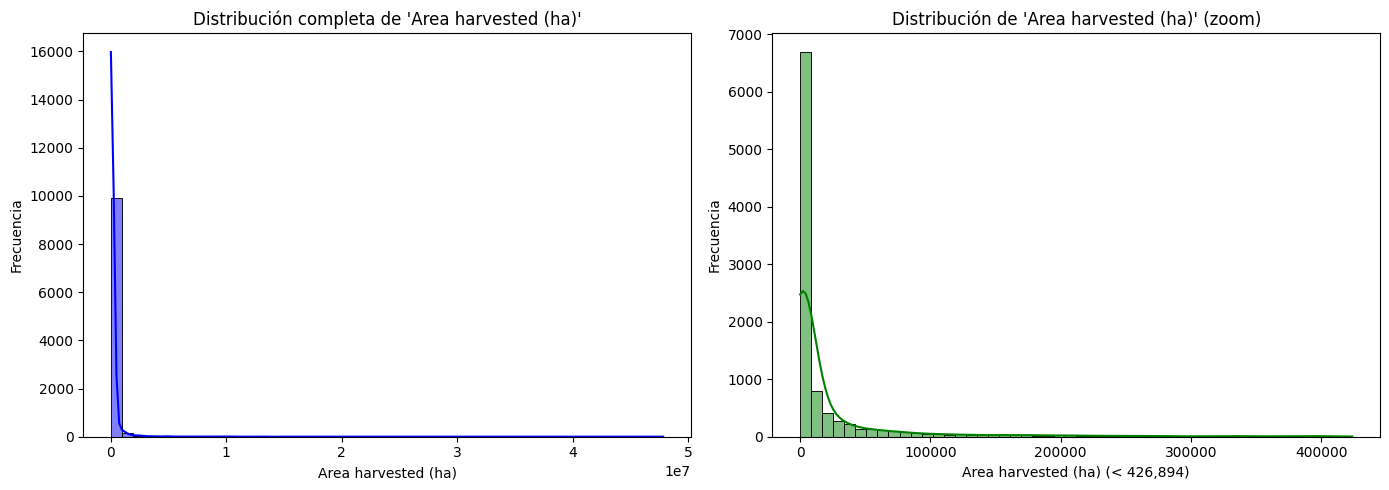

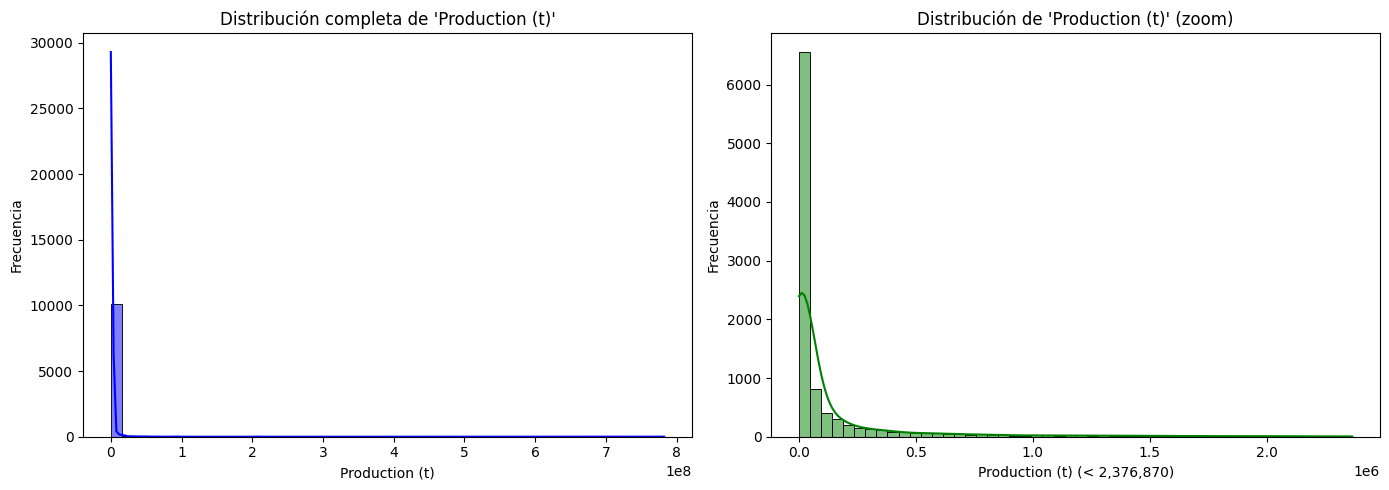

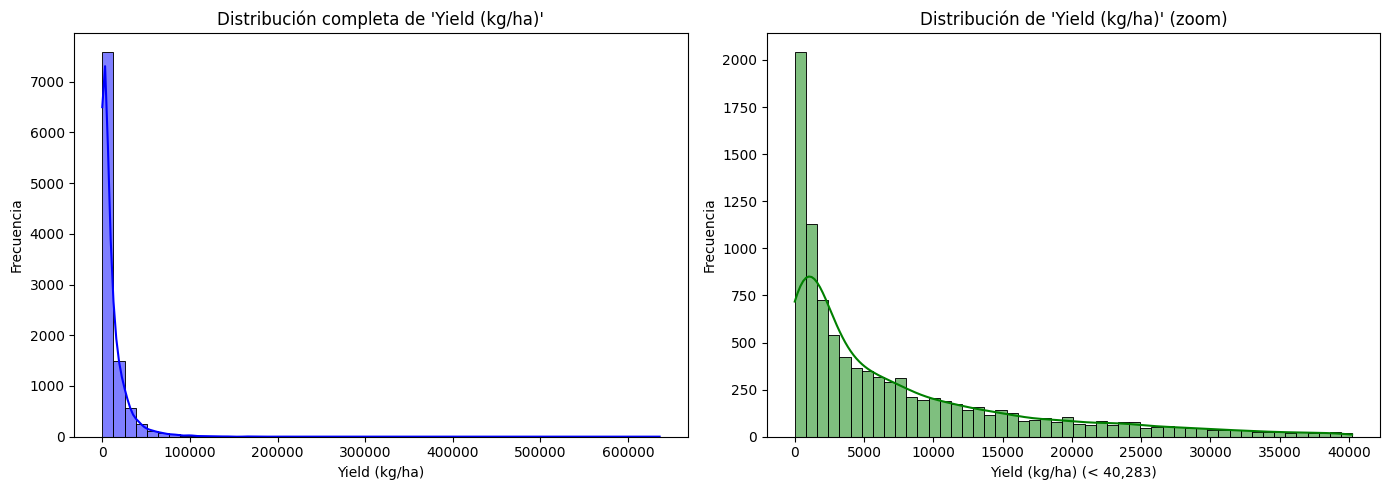

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_full_and_zoom(df, col, zoom_max=None, bins=50):
    x = df[col].dropna()
    if zoom_max is None:
        zoom_max = np.percentile(x, 95)  # zoom automático

    plt.figure(figsize=(14,5))

    # 1) Histograma completo
    plt.subplot(1,2,1)
    sns.histplot(x, bins=bins, kde=True, color='blue')
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.title(f"Distribución completa de '{col}'")

    # 2) Histograma con zoom
    plt.subplot(1,2,2)
    sns.histplot(x[x < zoom_max], bins=bins, kde=True, color='green')
    plt.xlabel(f"{col} (< {zoom_max:,.0f})")
    plt.ylabel("Frecuencia")
    plt.title(f"Distribución de '{col}' (zoom)")

    plt.tight_layout()
    plt.show()

# === Llamadas para las tres variables numéricas ===
plot_full_and_zoom(df_final, 'Area harvested (ha)')   # zoom por p95
plot_full_and_zoom(df_final, 'Production (t)')        # zoom por p95
plot_full_and_zoom(df_final, 'Yield (kg/ha)')         # zoom por p95


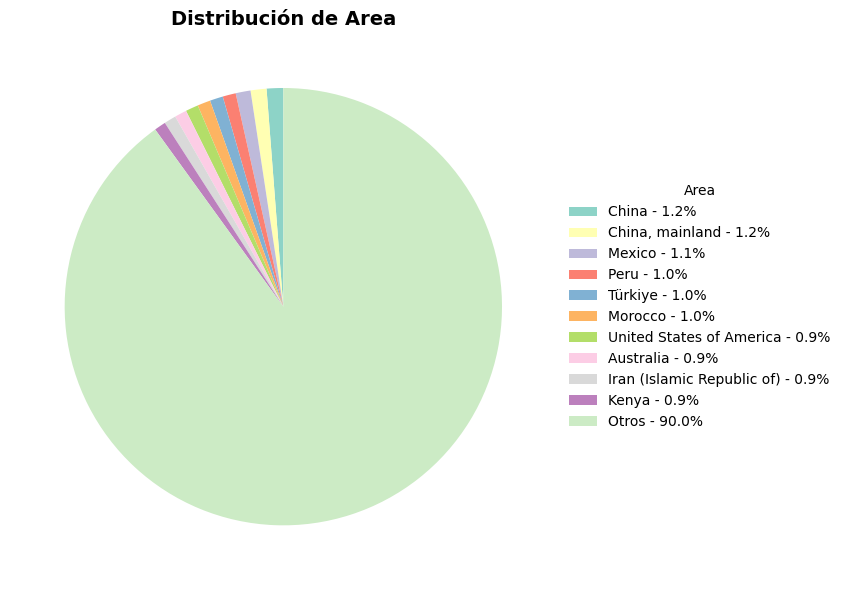

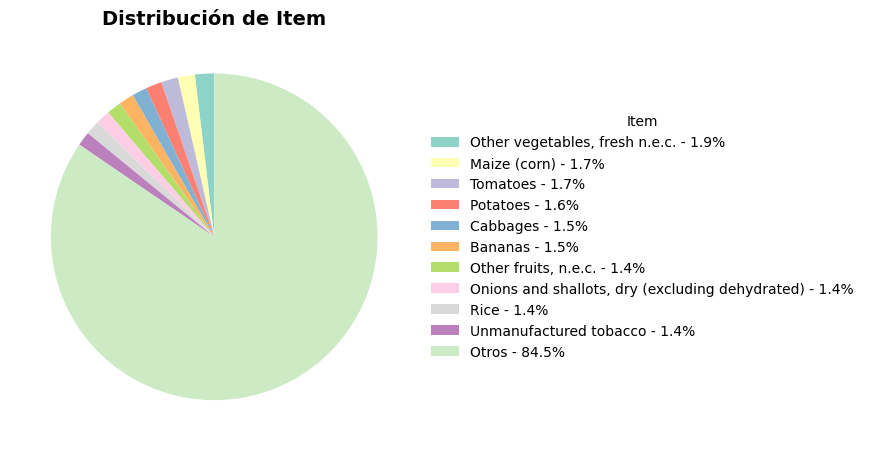

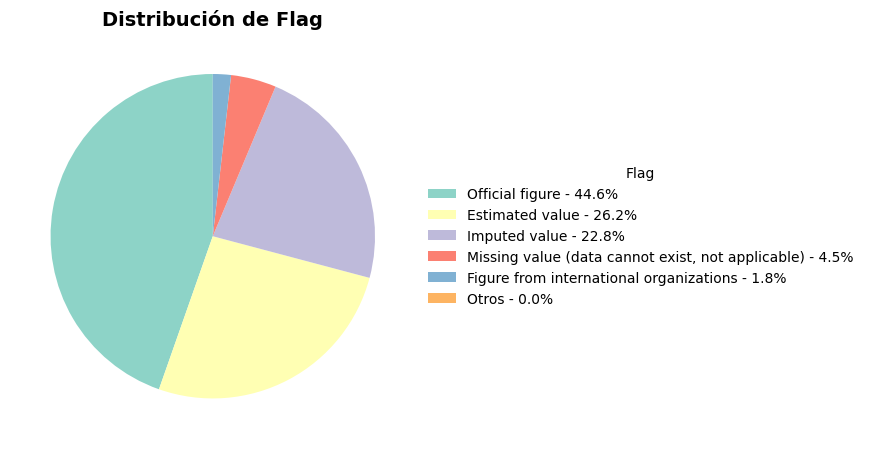

In [103]:
# Variables categóricas del nuevo dataset
categorical_columns = ['Area', 'Item', 'Flag']

for column in categorical_columns:
    # Contar las frecuencias
    value_counts = df_final[column].value_counts()

    # Seleccionar los 10 más grandes
    top_10 = value_counts.nlargest(10)

    # Agrupar el resto de los valores en "Otros"
    others = value_counts.iloc[10:].sum()
    data = pd.concat([top_10, pd.Series({'Otros': others})])

    # Calcular porcentajes
    percentages = data / data.sum() * 100

    # Crear gráfico de torta
    plt.figure(figsize=(8, 6))
    colors = plt.cm.Set3.colors  # paleta amigable
    ax = data.plot(kind='pie', startangle=90, colors=colors, labels=None)

    # Crear leyenda con nombre + porcentaje
    legend_labels = [f'{label} - {percentage:.1f}%' for label, percentage in zip(data.index, percentages)]
    plt.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.5), title=column, frameon=False)

    # Ajustes visuales
    plt.title(f'Distribución de {column}', fontsize=14, weight='bold')
    plt.ylabel('')  # quitar etiqueta de eje y
    plt.tight_layout()

    # Guardar el gráfico como archivo PNG
    plt.savefig(f'{column}_torta.png', bbox_inches='tight')  # Guarda la figura

    # Mostrar
    plt.show()
    print("\n")


# 5. **Definir la tarea**

Después de la limpieza y reestructuración del dataset, ahora contamos con un conjunto de variables que nos permiten plantear un problema de **aprendizaje supervisado**.  

Las **variables predictoras (X)** serán:  
- **Area harvested (ha):** superficie cosechada en hectáreas.  
- **Production (t):** producción total en toneladas.  
- **Yield (kg/ha):** rendimiento por hectárea.  
- **Item:** tipo de cultivo (ejemplo: arroz, maíz, trigo).  

La **variable objetivo (y)** será:  
- **Area:** el país al que pertenece el registro.  

Esto significa que la tarea a resolver se define como un **problema de clasificación multiclase**, donde el objetivo es **predecir a qué país corresponde un registro agrícola** a partir de sus características productivas y del cultivo al que hace referencia.  

Se decidió incluir la variable categórica **Item** porque cada cultivo tiene patrones de producción diferentes. De esta forma, el modelo no solo compara países por magnitudes numéricas, sino también por el tipo de cultivo, lo que hace que la clasificación sea más precisa y realista.  

En conclusión, nuestro proyecto abordará la tarea de **clasificación de países productores de cultivos agrícolas**, utilizando como entradas tanto las variables numéricas de producción como el tipo de cultivo. Esto nos permitirá capturar mejor la diversidad de contextos agrícolas y facilitar una interpretación más completa de los resultados.  

# 6. Segunda pre-entrega

**Cambio de enfoque del proyecto**

Inicialmente nuestro objetivo era clasificar el **país** en base a diferentes métricas del dataset. Sin embargo, al analizar los datos con más detalle, notamos que teníamos alrededor de **10.200 registros distribuidos en más de 200 países**, lo que generaba muy poca representación por clase y hacía que el modelo no lograra aprender patrones reales. Además, muchas de las variables no aportaban información significativa y los países se repetían casi con la misma frecuencia, lo cual dificultaba el proceso de entrenamiento y resultó en un **accuracy cercano a 0.02**, indicando que el modelo prácticamente no aprendía nada.  

Por esta razón decidimos **cambiar el enfoque del proyecto**: en lugar de predecir el país, ahora el modelo buscará **clasificar el continente o región** al que pertenece cada registro. De esta forma reducimos el número de clases a unas **6 o 7 categorías**, lo que hace el problema más realista y manejable, manteniendo la coherencia con la idea inicial.


In [104]:
#@title Refinación del dataset: creación de columna "Region"

#Agregar columna "Region" para reducir las clases a predecir.
import pycountry_convert as pc

#Función que convierte un país en su respectivo continente
def country_to_continent(country_name):
    try:
        #Obtener el código ISO del país (por ejemplo, "CO" para Colombia)
        country_code = pc.country_name_to_country_alpha2(country_name)
        #Obtener el código del continente (por ejemplo, "SA" para South America)
        continent_code = pc.country_alpha2_to_continent_code(country_code)

        #Mapa con los nombres de los continentes
        continent_map = {
            'AF': 'Africa',
            'AS': 'Asia',
            'EU': 'Europe',
            'NA': 'North America',
            'OC': 'Oceania',
            'SA': 'South America'
        }
        return continent_map[continent_code]
    except:
        #Si el país no se reconoce, se marca como "Other"
        return 'Other'

df_region = df_final.copy()
#Creamos la nueva columna "Region"
df_region['Region'] = df_region['Area'].apply(country_to_continent)

In [105]:
#@title Preparación básica de datos para el modelo

# Copia del dataset con la columna 'Region'
df_model = df_region.copy()

# Eliminar columnas que no aportan al modelo (retaining 'Area' for merge temporarily)
df_model.drop(columns=['Flag'], inplace=True) # Removed 'Area' from this drop

# Convertir columnas categóricas en valores numéricos
df_model['Region_refact'], _ = pd.factorize(df_model['Region'])
df_model['Item_refact'], _ = pd.factorize(df_model['Item'])

# Definir variables predictoras (X) y la variable objetivo (y)
X = df_model[['Item_refact', 'Area harvested (ha)', 'Production (t)', 'Yield (kg/ha)']]
y = df_model['Region_refact']

## **6.1. Particionado 80/20 y modelos base sin parámetros**

In [106]:
from sklearn.model_selection import train_test_split  # Para dividir el conjunto de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=21)

In [107]:
#@title **Decission Tree sin parametros**
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
est = DecisionTreeClassifier(random_state=21)
est.fit(X_train, y_train)
predictions = est.predict(X_test)
print(accuracy_score(predictions, y_test))

0.2957884427032321


In [108]:
#@title **Random Forest sin parametros**
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
est = RandomForestClassifier(random_state=21)
est.fit(X_train, y_train)
predictions = est.predict(X_test)
print(accuracy_score(predictions, y_test))

0.3731635651322233


In [109]:
#@title **SVC sin parametros**
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
est = SVC(random_state=21)
est.fit(X_train, y_train)
predictions = est.predict(X_test)
print(accuracy_score(predictions, y_test))

0.28795298726738494


## **6.2. Curvas de aprendizaje por hiperparámetro**

In [110]:
#@title Función general para curva de aprendizaje por hiperparámetro (80/20)
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

def show_curve_param(estimator_class, param_name, start, stop, step):
    """
    Genera la curva de aprendizaje variando un hiperparámetro.
    Usa el particionado 80/20 y mide el accuracy en cada iteración.
    """
    means = []
    param_range = range(start, stop, step)

    for val in param_range:
        # Crear modelo con el hiperparámetro actual
        est = estimator_class(**{param_name: val, 'random_state': 42})
        est.fit(X_train, y_train)
        y_pred = est.predict(X_test)

        # Calcular accuracy y almacenarlo
        acc = accuracy_score(y_test, y_pred)
        means.append(acc)

    # Convertir lista a array para graficar
    means = np.r_[means]

    # Gráfica estilo original
    plt.plot(param_range, means, color="black", marker="o", label="accuracy")
    plt.xlabel(param_name)
    plt.ylabel("accuracy")
    plt.title(f"Curva de aprendizaje ({estimator_class.__name__})")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Mostrar el valor más óptimo
    best_val = list(param_range)[np.argmax(means)]
    print(f"Mejor {param_name}: {best_val}  -->  Accuracy: {max(means):.4f}")


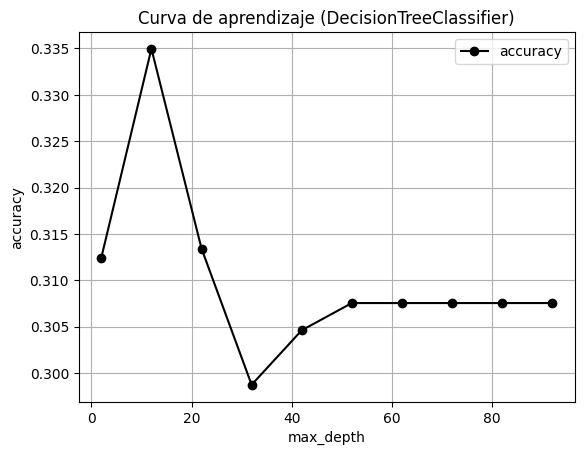

Mejor max_depth: 12  -->  Accuracy: 0.3350


In [111]:
#@title Curva de aprendizaje para Decision Tree
show_curve_param(DecisionTreeClassifier, 'max_depth', 2, 100, 10)

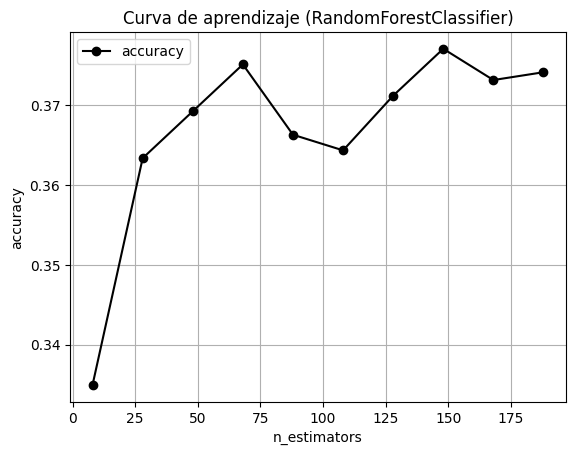

Mejor n_estimators: 148  -->  Accuracy: 0.3771


In [112]:
#@title Curva de aprendizaje para Random Forest
show_curve_param(RandomForestClassifier, 'n_estimators', 8, 200, 20)

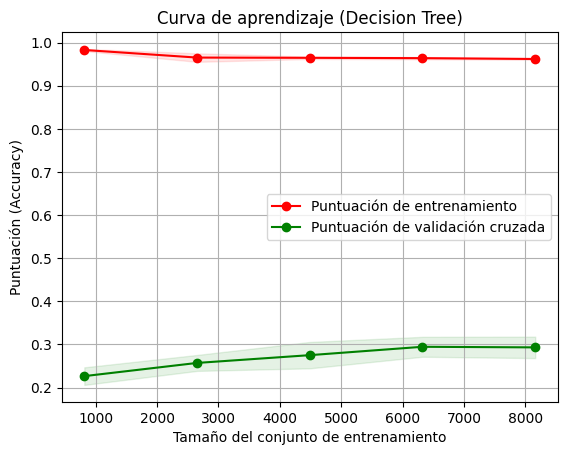

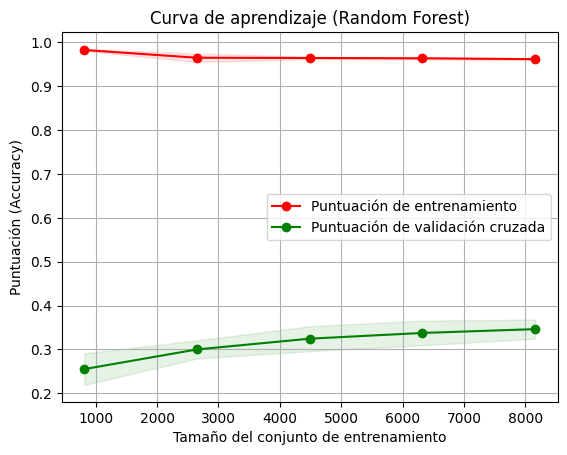

In [113]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

def plot_learning_curve(estimator, X, y, title, cv=5, n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    """
    Genera y plotea la curva de aprendizaje para un estimador dado.

    Args:
        estimator: Objeto estimador de scikit-learn.
        X: Datos de entrenamiento.
        y: Etiquetas de entrenamiento.
        title: Título para el gráfico.
        cv: Número de folds para la validación cruzada.
        n_jobs: Número de trabajos en paralelo (-1 usa todos los procesadores).
        train_sizes: Tamaños de subconjuntos del entrenamiento para la curva.
    """
    plt.figure()
    plt.title(title)
    plt.xlabel("Tamaño del conjunto de entrenamiento")
    plt.ylabel("Puntuación (Accuracy)")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Puntuación de entrenamiento")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Puntuación de validación cruzada")

    plt.legend(loc="best")
    return plt

# --- Generar curva de aprendizaje para Decision Tree ---
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier(random_state=21)
plot_learning_curve(dt_clf, X, y, "Curva de aprendizaje (Decision Tree)", cv=5)
plt.show()

# --- Generar curva de aprendizaje para Random Forest ---
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(random_state=21)
plot_learning_curve(rf_clf, X, y, "Curva de aprendizaje (Random Forest)", cv=5)
plt.show()

In [114]:
# #@title Comparación de kernels en SVC (gráfico de barras)
# # Lista de kernels a evaluar
# kernels = ['linear', 'poly', 'rbf']
# scores = []
#
# # Entrenar un modelo por cada kernel y medir el accuracy
# for k in kernels:
#     model = SVC(kernel=k, random_state=42)
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     acc = accuracy_score(y_test, y_pred)
#     scores.append(acc)
#
# # Crear gráfico de barras
# plt.figure(figsize=(8, 6))
# plt.bar(kernels, scores, color='skyblue', edgecolor='black')
# plt.xlabel("Kernel")
# plt.ylabel("Accuracy")
# plt.title("Comparación de kernels (SVC)")
# plt.grid(axis='y', linestyle='--', alpha=0.6)
# plt.ylim(0, 1) # Set y-axis limit to 0-1
# plt.show()
#
# # Mostrar resultados en texto
# for k, s in zip(kernels, scores):
#     print(f"Kernel: {k}  -->  Accuracy: {s:.4f}")
#
# # Mostrar el mejor kernel
# best_kernel = kernels[scores.index(max(scores))]
# print(f"\nMejor kernel: {best_kernel}  -->  Accuracy: {max(scores):.4f}")

In [115]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.svm import SVC
# from sklearn.metrics import accuracy_score
#
# # Definir la grilla de parámetros a buscar
# param_grid = {
#     'kernel': ['linear', 'poly', 'rbf'],
#     'C': [0.1, 1, 10, 100],
#     'gamma': ['scale', 'auto', 0.1, 1]
# }
#
# # Crear el modelo SVC
# svc = SVC(random_state=42)
#
# # Configurar GridSearchCV
# # cv=5 significa validación cruzada con 5 folds
# grid_search = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy')
#
# # Realizar la búsqueda en la grilla de parámetros
# print("Realizando búsqueda en grilla de parámetros...")
# grid_search.fit(X_train, y_train)
#
# # Mostrar los mejores parámetros encontrados
# print("\nMejores parámetros encontrados:")
# print(grid_search.best_params_)
#
# # Mostrar la mejor puntuación (accuracy) encontrada
# print("\nMejor puntuación (accuracy) encontrada:")
# print(grid_search.best_score_)
#
# # Opcional: Evaluar el mejor modelo en el conjunto de prueba
# best_model = grid_search.best_estimator_
# y_pred = best_model.predict(X_test)
# test_accuracy = accuracy_score(y_test, y_pred)
# print("\nAccuracy del mejor modelo en el conjunto de prueba:")
# print(test_accuracy)

In [116]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# --- Cross-validation para Decision Tree ---
dt_clf = DecisionTreeClassifier(random_state=21)
dt_scores = cross_val_score(dt_clf, X, y, cv=5, scoring='accuracy')
print("Accuracy de validación cruzada para Decision Tree:", dt_scores)
print("Accuracy promedio de validación cruzada para Decision Tree: {:.4f}".format(dt_scores.mean()))

print("-" * 30)

# --- Cross-validation para Random Forest ---
rf_clf = RandomForestClassifier(random_state=21)
rf_scores = cross_val_score(rf_clf, X, y, cv=5, scoring='accuracy')

rf_clf.fit(X_train, y_train)
y_pred = rf_clf.predict(X_test)
clasification_report = classification_report(y_test, y_pred)
print(clasification_report)
print("Accuracy de validación cruzada para Random Forest:", rf_scores)
print("Accuracy promedio de validación cruzada para Random Forest: {:.4f}".format(rf_scores.mean()))

Accuracy de validación cruzada para Decision Tree: [0.2822146  0.32582068 0.31323529 0.25392157 0.29411765]
Accuracy promedio de validación cruzada para Decision Tree: 0.2939
------------------------------
              precision    recall  f1-score   support

           0       0.27      0.33      0.30       233
           1       0.58      0.59      0.58       279
           2       0.43      0.45      0.44       255
           3       0.17      0.16      0.17        98
           4       0.10      0.06      0.07        51
           5       0.17      0.11      0.14        44
           6       0.03      0.02      0.02        61

    accuracy                           0.37      1021
   macro avg       0.25      0.25      0.25      1021
weighted avg       0.36      0.37      0.36      1021

Accuracy de validación cruzada para Random Forest: [0.3400294  0.37971583 0.35245098 0.31372549 0.34264706]
Accuracy promedio de validación cruzada para Random Forest: 0.3457


In [117]:
# #@title SVC con kernel = 'linear'
#
# print("Entrenando kernel: linear...")
# model_linear = SVC(kernel='linear', random_state=42)
# model_linear.fit(X_train, y_train)
# y_pred_linear = model_linear.predict(X_test)
# acc_linear = accuracy_score(y_test, y_pred_linear)
#
# plt.bar(['linear'], [acc_linear], color='skyblue', edgecolor='black')
# plt.title("Accuracy con kernel = linear")
# plt.ylabel("Accuracy")
# plt.ylim(0, 1)
# plt.grid(axis='y', alpha=0.5)
# plt.show()
#
# print(f"Accuracy (linear): {acc_linear:.4f}")

In [118]:
# #@title SVC con kernel = 'poly'
# print("Entrenando kernel: poly...")
# model_poly = SVC(kernel='poly', random_state=42)
# model_poly.fit(X_train, y_train)
# y_pred_poly = model_poly.predict(X_test)
# acc_poly = accuracy_score(y_test, y_pred_poly)
#
# plt.bar(['poly'], [acc_poly], color='skyblue', edgecolor='black')
# plt.title("Accuracy con kernel = poly")
# plt.ylabel("Accuracy")
# plt.ylim(0, 1)
# plt.grid(axis='y', alpha=0.5)
# plt.show()
#
# print(f"Accuracy (poly): {acc_poly:.4f}")

In [119]:
# #@title SVC con kernel = 'rbf'
# print("Entrenando kernel: rbf...")
# model_rbf = SVC(kernel='rbf', random_state=42)
# model_rbf.fit(X_train, y_train)
# y_pred_rbf = model_rbf.predict(X_test)
# acc_rbf = accuracy_score(y_test, y_pred_rbf)
#
# plt.bar(['rbf'], [acc_rbf], color='skyblue', edgecolor='black')
# plt.title("Accuracy con kernel = rbf")
# plt.ylabel("Accuracy")
# plt.ylim(0, 1)
# plt.grid(axis='y', alpha=0.5)
# plt.show()
#
# print(f"Accuracy (rbf): {acc_rbf:.4f}")

## Pruebas para ver porque no generalizaba nuestro modelo

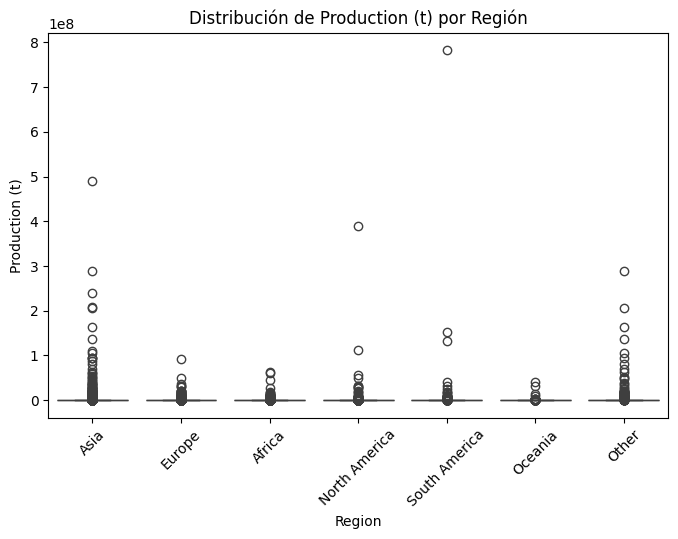

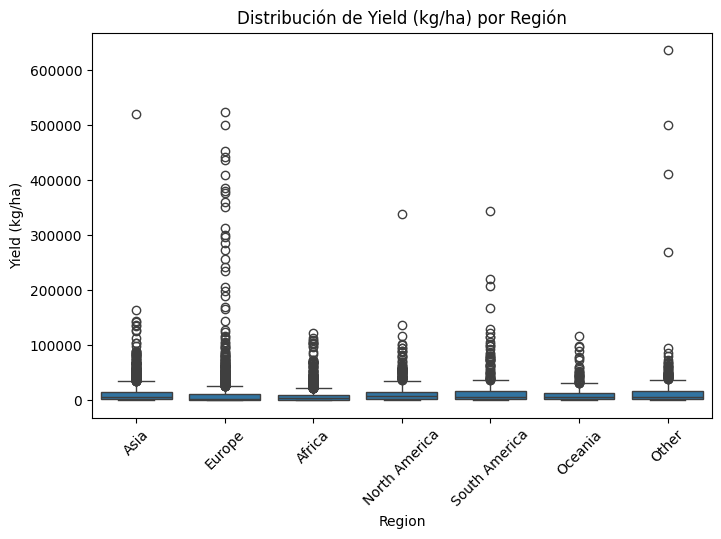

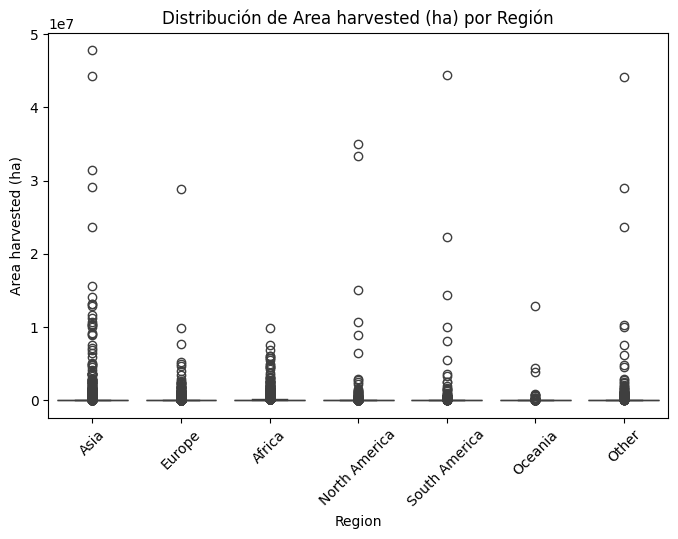

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ['Production (t)', 'Yield (kg/ha)', 'Area harvested (ha)']

for col in numeric_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='Region', y=col, data=df_region)
    plt.title(f'Distribución de {col} por Región')
    plt.xticks(rotation=45)
    plt.show()


In [121]:
df_region.groupby('Region')[['Production (t)', 'Yield (kg/ha)', 'Area harvested (ha)']].agg(['mean', 'std'])


Production (t)               Yield (kg/ha)                \
                        mean           std          mean           std   
Region                                                                   
Africa          4.438612e+05  2.434810e+06   7762.898304  12514.767609   
Asia            1.959606e+06  1.581522e+07  11729.441524  19036.175476   
Europe          4.251380e+05  2.881651e+06  12042.490553  35792.848480   
North America   9.674998e+05  1.242743e+07  12373.378578  18319.298387   
Oceania         3.001019e+05  2.597522e+06  10855.745111  14849.215427   
Other           3.309064e+06  1.878136e+07  14274.708885  39848.721382   
South America   2.292731e+06  3.174601e+07  14169.613210  25928.313003   

              Area harvested (ha)                
                             mean           std  
Region                                           
Africa              130086.890632  5.508687e+05  
Asia                255483.402872  1.911244e+06  
Europe               73743.474768  6.949976e+05  
North America       136498.650571  1.575359e+06  
Oceania              63844.280000  6.706170e+05  
Other               330863.785137  2.448048e+06  
South America       235517.431644  2.112720e+06

In [122]:
from scipy.stats import f_oneway

for col in numeric_cols:
    samples = [group[col].dropna() for name, group in df_region.groupby('Region')]
    f, p = f_oneway(*samples)
    print(f"{col}: F = {f:.2f}, p-value = {p:.5f}")


Production (t): F = 8.15, p-value = 0.00000
Yield (kg/ha): F = 11.65, p-value = 0.00000
Area harvested (ha): F = 5.73, p-value = 0.00001


In [123]:
pd.crosstab(df_region['Item'], df_region['Region']).head(10)


Region,Africa,Asia,Europe,North America,Oceania,Other,South America
Item,,,,,,,
"Abaca, manila hemp, raw",2,3,0,1,0,0,1
"Agave fibres, raw, n.e.c.",0,1,0,5,0,0,2
"Almonds, in shell",8,24,24,2,1,3,4
"Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw",11,11,5,3,1,2,3
Apples,10,25,37,8,2,6,8
Apricots,10,24,33,3,2,4,4
Areca nuts,0,11,0,0,0,1,0
Artichokes,7,11,18,3,0,2,3
Asparagus,8,8,23,4,2,4,5


                     Production (t)  Yield (kg/ha)  Area harvested (ha)
Production (t)             1.000000       0.058298             0.634267
Yield (kg/ha)              0.058298       1.000000            -0.019465
Area harvested (ha)        0.634267      -0.019465             1.000000


<Axes: >

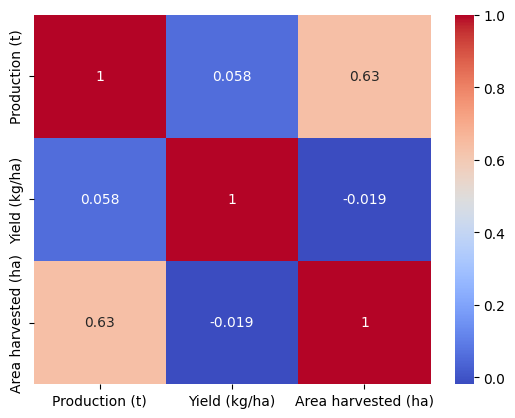

In [124]:
corr = df_region[['Production (t)', 'Yield (kg/ha)', 'Area harvested (ha)']].corr()
print(corr)
sns.heatmap(corr, annot=True, cmap='coolwarm')


# **Entrega Final DNN**

In [125]:
#@title **Import libraries**

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(21)
tf.keras.utils.set_random_seed(21)
np.random.seed(21)

In [126]:
X = df_model[['Item_refact', 'Area harvested (ha)', 'Production (t)', 'Yield (kg/ha)']]
y = df_model['Region_refact']
df_model.head()

,Area,Item,Area harvested (ha),Production (t),Yield (kg/ha),Region,Region_refact,Item_refact
0,Afghanistan,"Almonds, in shell",37000.0,67000.00,1810.8,Asia,0,0
1,Afghanistan,"Anise, badian, coriander, cumin, caraway, fenn...",25439.0,17908.59,704.0,Asia,0,1
2,Afghanistan,Apples,31000.0,324000.00,10451.6,Asia,0,2
3,Afghanistan,Apricots,22008.0,155429.38,7062.4,Asia,0,3
4,Afghanistan,Barley,80000.0,110000.00,1375.0,Asia,0,4


In [127]:
from sklearn.preprocessing import StandardScaler
nc = len(np.unique(y))

# Crear una instancia de StandardScaler
scaler = StandardScaler()

# Ajustar el escalador a las columnas numéricas y transformarlas.
# Suponiendo que «Item_refact» ya es adecuado como codificación categórica.
X[['Area harvested (ha)', 'Production (t)', 'Yield (kg/ha)']] = scaler.fit_transform(X[['Area harvested (ha)', 'Production (t)', 'Yield (kg/ha)']])
# Remove column names
X.columns = range(X.shape[1])
X = X.to_numpy()
y = y.to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

/tmp/ipython-input-1921543815.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[['Area harvested (ha)', 'Production (t)', 'Yield (kg/ha)']] = scaler.fit_transform(X[['Area harvested (ha)', 'Production (t)', 'Yield (kg/ha)']])


In [128]:
#@title Primera red neuronal
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(nc, activation='softmax')
])

model.compile(
  optimizer=tf.keras.optimizers.SGD(),
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

hist = model.fit(X_train, y_train, epochs = 30)
accuracy = hist.history['accuracy']
print("Accuracy: ", accuracy)
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Pérdida del modelo: ", test_loss)
print("Exactitud del modelo: ", test_acc)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2353 - loss: 2.2817
Epoch 2/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2573 - loss: 1.8253
Epoch 3/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2554 - loss: 1.8094
Epoch 4/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2610 - loss: 1.7975
Epoch 5/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2580 - loss: 1.7891
Epoch 6/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2546 - loss: 1.7831
Epoch 7/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2596 - loss: 1.7764
Epoch 8/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2593 - loss: 1.7721
Epoch 9/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2568 - loss: 1.7693
Epoch 10/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2574 - loss: 1.7679
Epoch 11/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2663 - loss: 1.7662
Epoch 12/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy

- El accuracy durante el entrenamiento subió de ~0.23 a ~0.27, mostrando un aprendizaje leve pero estable.

- La exactitud en test quedó en ~0.264, muy similar al entrenamiento → el modelo no sobreajusta, simplemente aprende poco (underfiting).

- La pérdida en test (1.73) sigue siendo alta, indicando que la red se equivoca bastante.

En resumen: este modelo sirve como línea base, pero su precisión es baja y requiere una arquitectura más grande o más preprocesamiento para mejorar.

In [129]:
#@title Segunda red neuronal
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(nc, activation='softmax')
])

model.compile(
  optimizer=tf.keras.optimizers.SGD(),
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

hist = model.fit(X_train, y_train, epochs = 30)
accuracy = hist.history['accuracy']
print("Accuracy: ", accuracy)
test_loss, test_acc = model.evaluate(X_test, y_test)
print("pérdida del modelo: ", test_loss)
print("exactitud del modelo: ", test_acc)

Epoch 1/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2304 - loss: 2.5688
Epoch 2/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2566 - loss: 1.8247
Epoch 3/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2633 - loss: 1.8074
Epoch 4/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2574 - loss: 1.7955
Epoch 5/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2550 - loss: 1.7859
Epoch 6/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2651 - loss: 1.7794
Epoch 7/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2637 - loss: 1.7748
Epoch 8/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2559 - loss: 1.7712
Epoch 9/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2573 - loss: 1.7701
Epoch 10/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2584 - loss: 1.7685
Epoch 11/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2626 - loss: 1.7660
Epoch 12/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

- El accuracy de entrenamiento aumentó de ~0.24 a ~0.27, mostrando un patrón de aprendizaje muy similar al primer modelo, aunque con capas más grandes (mayor cantidad de neuronas).

- La exactitud en test quedó en ~0.265, prácticamente igual al entrenamiento → no hay overfitting, pero el desempeño sigue siendo bajo.

- La pérdida en test (~1.72) es alta, indicando que la red aún tiene dificultades para separar correctamente las clases.

En general, este segundo modelo también presenta underfitting, ya que incluso con más neuronas no logra capturar patrones más complejos del dataset.

In [130]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(nc, activation='softmax')
])

model.compile(
  optimizer=tf.keras.optimizers.SGD(),
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

hist = model.fit(X_train, y_train, epochs = 30)
accuracy = hist.history['accuracy']
print("Accuracy: ", accuracy)
test_loss, test_acc = model.evaluate(X_test, y_test)
print("pérdida del modelo: ", test_loss)
print("exactitud del modelo: ", test_acc)

Epoch 1/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2297 - loss: 2.5164
Epoch 2/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2545 - loss: 1.8199
Epoch 3/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2493 - loss: 1.8036
Epoch 4/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2555 - loss: 1.7927
Epoch 5/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2557 - loss: 1.7829
Epoch 6/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2546 - loss: 1.7744
Epoch 7/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2544 - loss: 1.7727
Epoch 8/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2604 - loss: 1.7690
Epoch 9/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2563 - loss: 1.7657
Epoch 10/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2596 - loss: 1.7641
Epoch 11/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2628 - loss: 1.7641
Epoch 12/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

- El accuracy de entrenamiento aumentó de ~0.26 a ~0.27, mostrando una mejora ligeramente mayor frente a los dos modelos anteriores pero solo iniciando el entrenamiento.

- La exactitud en test fue ~0.278, la más alta de los tres modelos, aunque sigue siendo baja en términos absolutos.

- La pérdida en test (~1.72) continúa siendo alta, lo que indica que el modelo sigue teniendo dificultades para aprender patrones complejos.

En general, aunque este modelo tiene el mejor desempeño relativo, aún presenta underfitting, ya que tanto entrenamiento como prueba mantienen accuracies bajas y similares.

### **Enriquecimiento del dataset con latitud y distancia al ecuador**

Para desarrollar la hipótesis de si la distancia al ecuador podría mejorar la precisión del modelo, necesitamos obtener la latitud de cada país presente en el datasetpara calcular una medida de la distancia al ecuador.

Utilizamos la librería `geopy` para obtener la latitud y longitud de cada país. Este proceso es poco lento, así que guardaremos los resultados en un archivo CSV y una vez que tenemos la nueva propiedad `Distance_from_Equator`, podemos incorporarla en nuestro modelo de clasificación.

Finalmente, vamos a entrenar y evaluar el modelo de red neuronal con la nueva característica `Distance_from_Equator` y comparar su rendimiento con los modelos anteriores.

In [131]:
#@title Instalar librería geopy
!pip install geopy --quiet

In [132]:
#@title Obtener latitud y calcular distancia al ecuador
from geopy.geocoders import Nominatim
import pandas as pd
import numpy as np
import os

# Obtener la lista única de países (áreas) de df_final
countries = df_final['Area'].unique()

geolocator = Nominatim(user_agent="geo_colab_app") # Asegúrate de usar un user_agent único

# Archivo para guardar/cargar las coordenadas
coordinates_file = f"{REPO_DIR}/data/country_coordinates.csv"

# Cargar coordenadas si el archivo existe
if os.path.exists(coordinates_file):
    country_coords = pd.read_csv(coordinates_file)
    print("Coordenadas de países cargadas desde archivo.")
else:
    # Si no existe, obtener coordenadas y guardarlas
    country_coords = []
    for country in countries:
        try:
            location = geolocator.geocode(country, timeout=10)
            if location:
                country_coords.append({'Area': country, 'Latitude': location.latitude, 'Longitude': location.longitude})
            else:
                country_coords.append({'Area': country, 'Latitude': np.nan, 'Longitude': np.nan})
            print(f"Obtenidas coordenadas para {country}")
        except Exception as e:
            print(f"Error al obtener coordenadas para {country}: {e}")
            country_coords.append({'Area': country, 'Latitude': np.nan, 'Longitude': np.nan})
    country_coords = pd.DataFrame(country_coords)
    country_coords.to_csv(coordinates_file, index=False)
    print("Coordenadas de países obtenidas y guardadas en archivo.")

# Unir las coordenadas al df_model
df_model_enriched = df_model.merge(country_coords, on='Area', how='left')

# Calcular la distancia absoluta a la latitud 0 (ecuador)
df_model_enriched['Distance_from_Equator'] = df_model_enriched['Latitude'].abs()

# Manejar NaNs en la nueva columna (por ejemplo, rellenar con la media o 0, o eliminar filas)
df_model_enriched['Distance_from_Equator'] = df_model_enriched['Distance_from_Equator'].fillna(df_model_enriched['Distance_from_Equator'].mean())

print("\nDataFrame enriquecido con 'Latitude', 'Longitude' y 'Distance_from_Equator':")
display(df_model_enriched.head())

Coordenadas de países cargadas desde archivo.

DataFrame enriquecido con 'Latitude', 'Longitude' y 'Distance_from_Equator':


,Area,Item,Area harvested (ha),Production (t),Yield (kg/ha),Region,Region_refact,Item_refact,Latitude,Longitude,Distance_from_Equator
0,Afghanistan,"Almonds, in shell",37000.0,67000.00,1810.8,Asia,0,0,33.768006,66.238514,33.768006
1,Afghanistan,"Anise, badian, coriander, cumin, caraway, fenn...",25439.0,17908.59,704.0,Asia,0,1,33.768006,66.238514,33.768006
2,Afghanistan,Apples,31000.0,324000.00,10451.6,Asia,0,2,33.768006,66.238514,33.768006
3,Afghanistan,Apricots,22008.0,155429.38,7062.4,Asia,0,3,33.768006,66.238514,33.768006
4,Afghanistan,Barley,80000.0,110000.00,1375.0,Asia,0,4,33.768006,66.238514,33.768006


In [133]:
#@title Preparación de datos con 'Distance_from_Equator'

# Definir las nuevas variables predictoras (X) y la variable objetivo (y)
X_enriched = df_model_enriched[['Item_refact', 'Area harvested (ha)', 'Production (t)', 'Yield (kg/ha)', 'Distance_from_Equator']]
y_enriched = df_model_enriched['Region_refact']

# Escalar las características numéricas, incluyendo la nueva columna
scaler_enriched = StandardScaler()
X_enriched[['Area harvested (ha)', 'Production (t)', 'Yield (kg/ha)', 'Distance_from_Equator']] = scaler_enriched.fit_transform(X_enriched[['Area harvested (ha)', 'Production (t)', 'Yield (kg/ha)', 'Distance_from_Equator']])

# Convertir a numpy arrays
X_enriched.columns = range(X_enriched.shape[1])
X_enriched = X_enriched.to_numpy()
y_enriched = y_enriched.to_numpy()

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_enriched, X_test_enriched, y_train_enriched, y_test_enriched = train_test_split(X_enriched, y_enriched, test_size=0.2, random_state=21)

print("Datos preparados con 'Distance_from_Equator'.")


Datos preparados con 'Distance_from_Equator'.


/tmp/ipython-input-746839752.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_enriched[['Area harvested (ha)', 'Production (t)', 'Yield (kg/ha)', 'Distance_from_Equator']] = scaler_enriched.fit_transform(X_enriched[['Area harvested (ha)', 'Production (t)', 'Yield (kg/ha)', 'Distance_from_Equator']])


## **Re-evaluación de las redes neuronales con 'Distance_from_Equator'**

Vamos a ejecutar nuevamente las primeras dos configuraciones de redes neuronales, pero esta vez utilizando el dataset enriquecido que incluye la característica 'Distance_from_Equator'. Esto nos permitirá observar cómo esta nueva información impacta en su desempeño.

In [140]:
#@title Primera red neuronal (re-ejecutada con 'Distance_from_Equator')

model_nn1_enriched = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(X_train_enriched.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(nc, activation='softmax')
])

model_nn1_enriched.compile(
  optimizer=tf.keras.optimizers.SGD(),
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

hist_nn1_enriched = model_nn1_enriched.fit(X_train_enriched, y_train_enriched, epochs = 30, verbose=0)
accuracy_nn1_enriched = hist_nn1_enriched.history['accuracy']
print("Accuracy del entrenamiento: ", accuracy_nn1_enriched[-1])

test_loss_nn1_enriched, test_acc_nn1_enriched = model_nn1_enriched.evaluate(X_test_enriched, y_test_enriched)
print("Pérdida del modelo (test): ", test_loss_nn1_enriched)
print("Exactitud del modelo (test): ", test_acc_nn1_enriched)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Accuracy del entrenamiento:  0.5028795599937439
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5534 - loss: 1.3228
Pérdida del modelo (test):  1.3446059226989746
Exactitud del modelo (test):  0.5355218052864075


In [139]:
#@title Segunda red neuronal (re-ejecutada con 'Distance_from_Equator')

model_nn2_enriched = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(X_train_enriched.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(nc, activation='softmax')
])

model_nn2_enriched.compile(
  optimizer=tf.keras.optimizers.SGD(),
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

hist_nn2_enriched = model_nn2_enriched.fit(X_train_enriched, y_train_enriched, epochs = 30, verbose=0)
accuracy_nn2_enriched = hist_nn2_enriched.history['accuracy']
print("Accuracy del entrenamiento: ", accuracy_nn2_enriched[-1])

test_loss_nn2_enriched, test_acc_nn2_enriched = model_nn2_enriched.evaluate(X_test_enriched, y_test_enriched)
print("Pérdida del modelo (test): ", test_loss_nn2_enriched)
print("Exactitud del modelo (test): ", test_acc_nn2_enriched)


Accuracy del entrenamiento:  0.49797818064689636
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5463 - loss: 1.3185
Pérdida del modelo (test):  1.3399335145950317
Exactitud del modelo (test):  0.5340519547462463
